<a href="https://colab.research.google.com/github/rhyan-rpone/ai-and-data_analysis-notebooks/blob/main/enterprise_sales_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

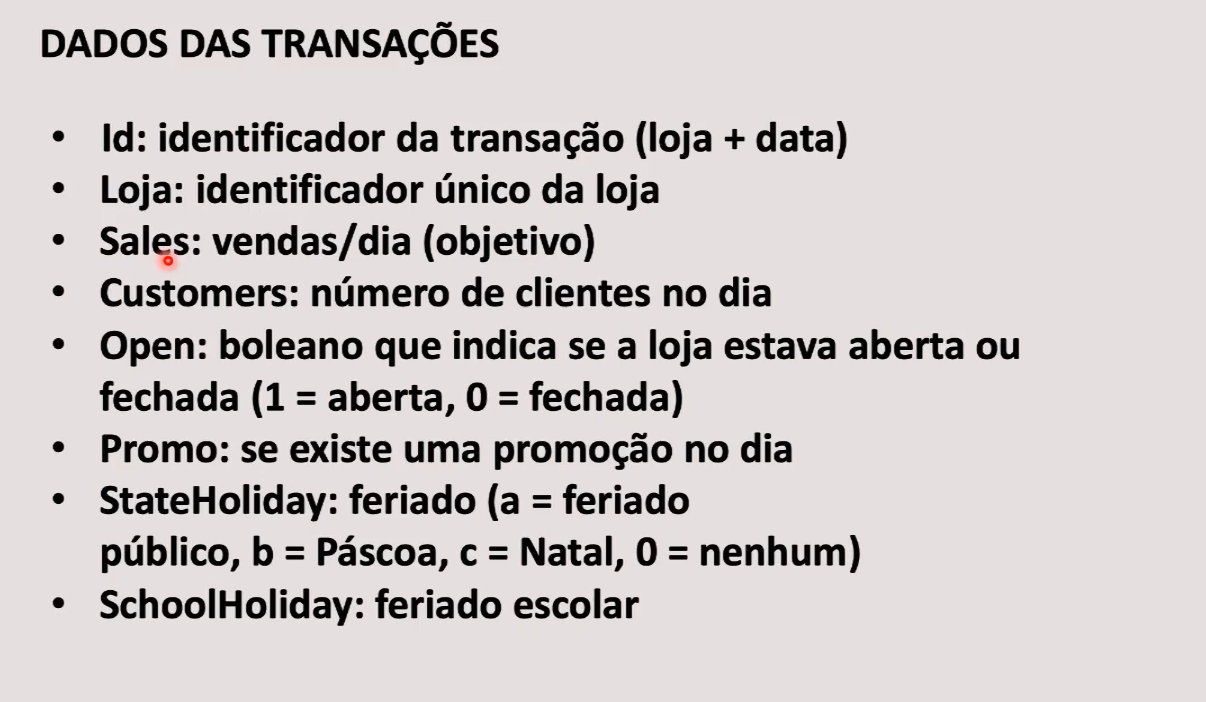

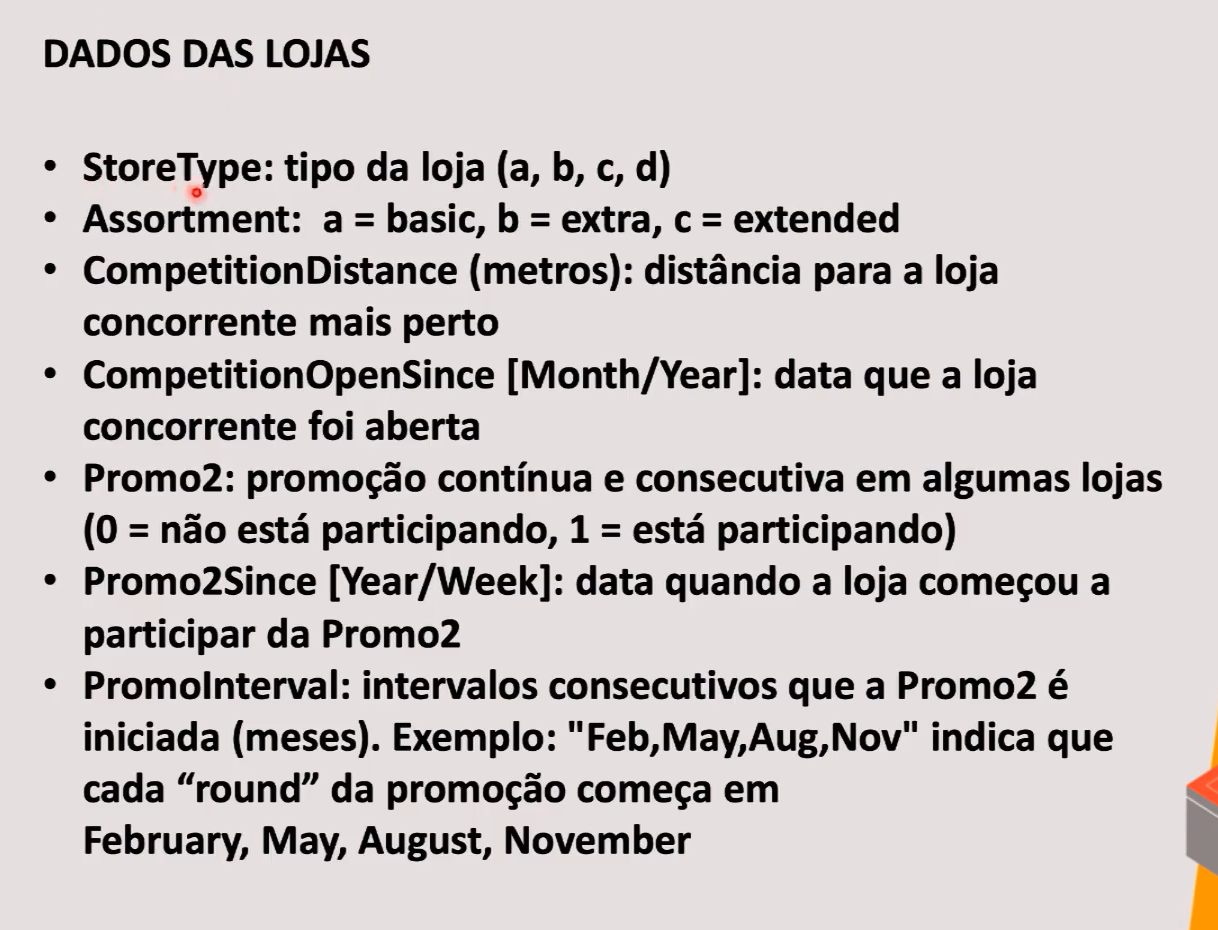

## Importação das bibliotecas e base de dados

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import warnings

### Dados das vendas

In [ ]:
sales_train_df = pd.read_csv('/content/train.csv')

/tmp/ipykernel_144/2118151063.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_train_df = pd.read_csv('/content/train.csv')


In [ ]:
sales_train_df.shape

(532483, 9)

In [ ]:
sales_train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5.0,2015-07-31,5263.0,555.0,1.0,1.0,0,1.0
1,2,5.0,2015-07-31,6064.0,625.0,1.0,1.0,0,1.0
2,3,5.0,2015-07-31,8314.0,821.0,1.0,1.0,0,1.0
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,1.0,0,1.0
4,5,5.0,2015-07-31,4822.0,559.0,1.0,1.0,0,1.0


In [ ]:
sales_train_df['DayOfWeek'].unique()

array([ 5.,  4.,  3.,  2.,  1.,  7.,  6., nan])

In [ ]:
sales_train_df['Open'].unique()

array([ 1.,  0., nan])

In [ ]:
sales_train_df['Promo'].unique()

array([ 1.,  0., nan])

In [ ]:
sales_train_df['StateHoliday'].unique()

array(['0', 'a', 'b', 'c', 0, nan], dtype=object)

In [ ]:
sales_train_df['SchoolHoliday'].unique()

array([ 1.,  0., nan])

In [ ]:
sales_train_df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
532478,294,2.0,2014-03-11,6207.0,915.0,1.0,0.0,0.0,0.0
532479,295,2.0,2014-03-11,4178.0,585.0,1.0,0.0,0.0,0.0
532480,296,2.0,2014-03-11,5643.0,737.0,1.0,0.0,0.0,0.0
532481,297,2.0,2014-03-11,5029.0,624.0,1.0,0.0,0.0,0.0
532482,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sales_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532483 entries, 0 to 532482
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Store          532483 non-null  int64  
 1   DayOfWeek      532482 non-null  float64
 2   Date           532482 non-null  object 
 3   Sales          532482 non-null  float64
 4   Customers      532482 non-null  float64
 5   Open           532482 non-null  float64
 6   Promo          532482 non-null  float64
 7   StateHoliday   532482 non-null  object 
 8   SchoolHoliday  532482 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 36.6+ MB


In [ ]:
sales_train_df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,532483.000000,532482.000000,532482.000000,532482.000000,532482.000000,532482.000000,532482.000000
mean,558.592550,3.999899,5886.155797,637.774283,0.828588,0.393779,0.182220
std,322.003787,1.995014,3898.466096,467.209663,0.376869,0.488587,0.386026
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,281.000000,2.000000,3827.000000,413.000000,1.000000,0.000000,0.000000
50%,558.000000,4.000000,5884.000000,616.000000,1.000000,0.000000,0.000000
75%,838.000000,6.000000,8020.000000,842.000000,1.000000,1.000000,0.000000
max,1115.000000,7.000000,41551.000000,5494.000000,1.000000,1.000000,1.000000


# Dados das lojas

In [ ]:
store_info_df = pd.read_csv('/content/store.csv')

In [ ]:
store_info_df.shape

(1115, 10)

In [ ]:
store_info_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
store_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [ ]:
store_info_df.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


# Exploração dos dados

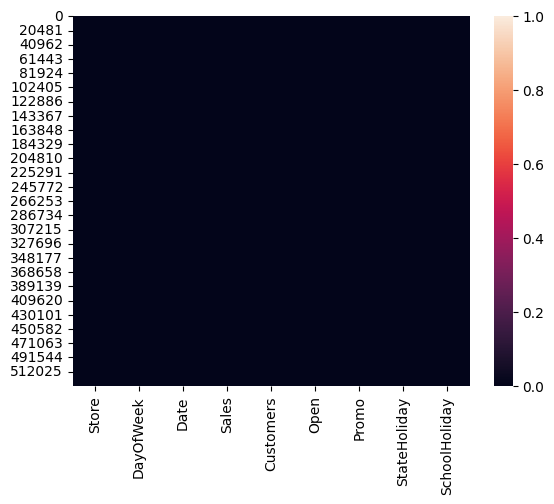

In [ ]:
sns.heatmap(sales_train_df.isnull());

In [ ]:
sales_train_df.isnull().sum()

,0
Store,0
DayOfWeek,1
Date,1
Sales,1
Customers,1
Open,1
Promo,1
StateHoliday,1
SchoolHoliday,1


array([[<Axes: title={'center': 'Store'}>,
        <Axes: title={'center': 'DayOfWeek'}>,
        <Axes: title={'center': 'Sales'}>],
       [<Axes: title={'center': 'Customers'}>,
        <Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'Promo'}>],
       [<Axes: title={'center': 'SchoolHoliday'}>, <Axes: >, <Axes: >]],
      dtype=object)

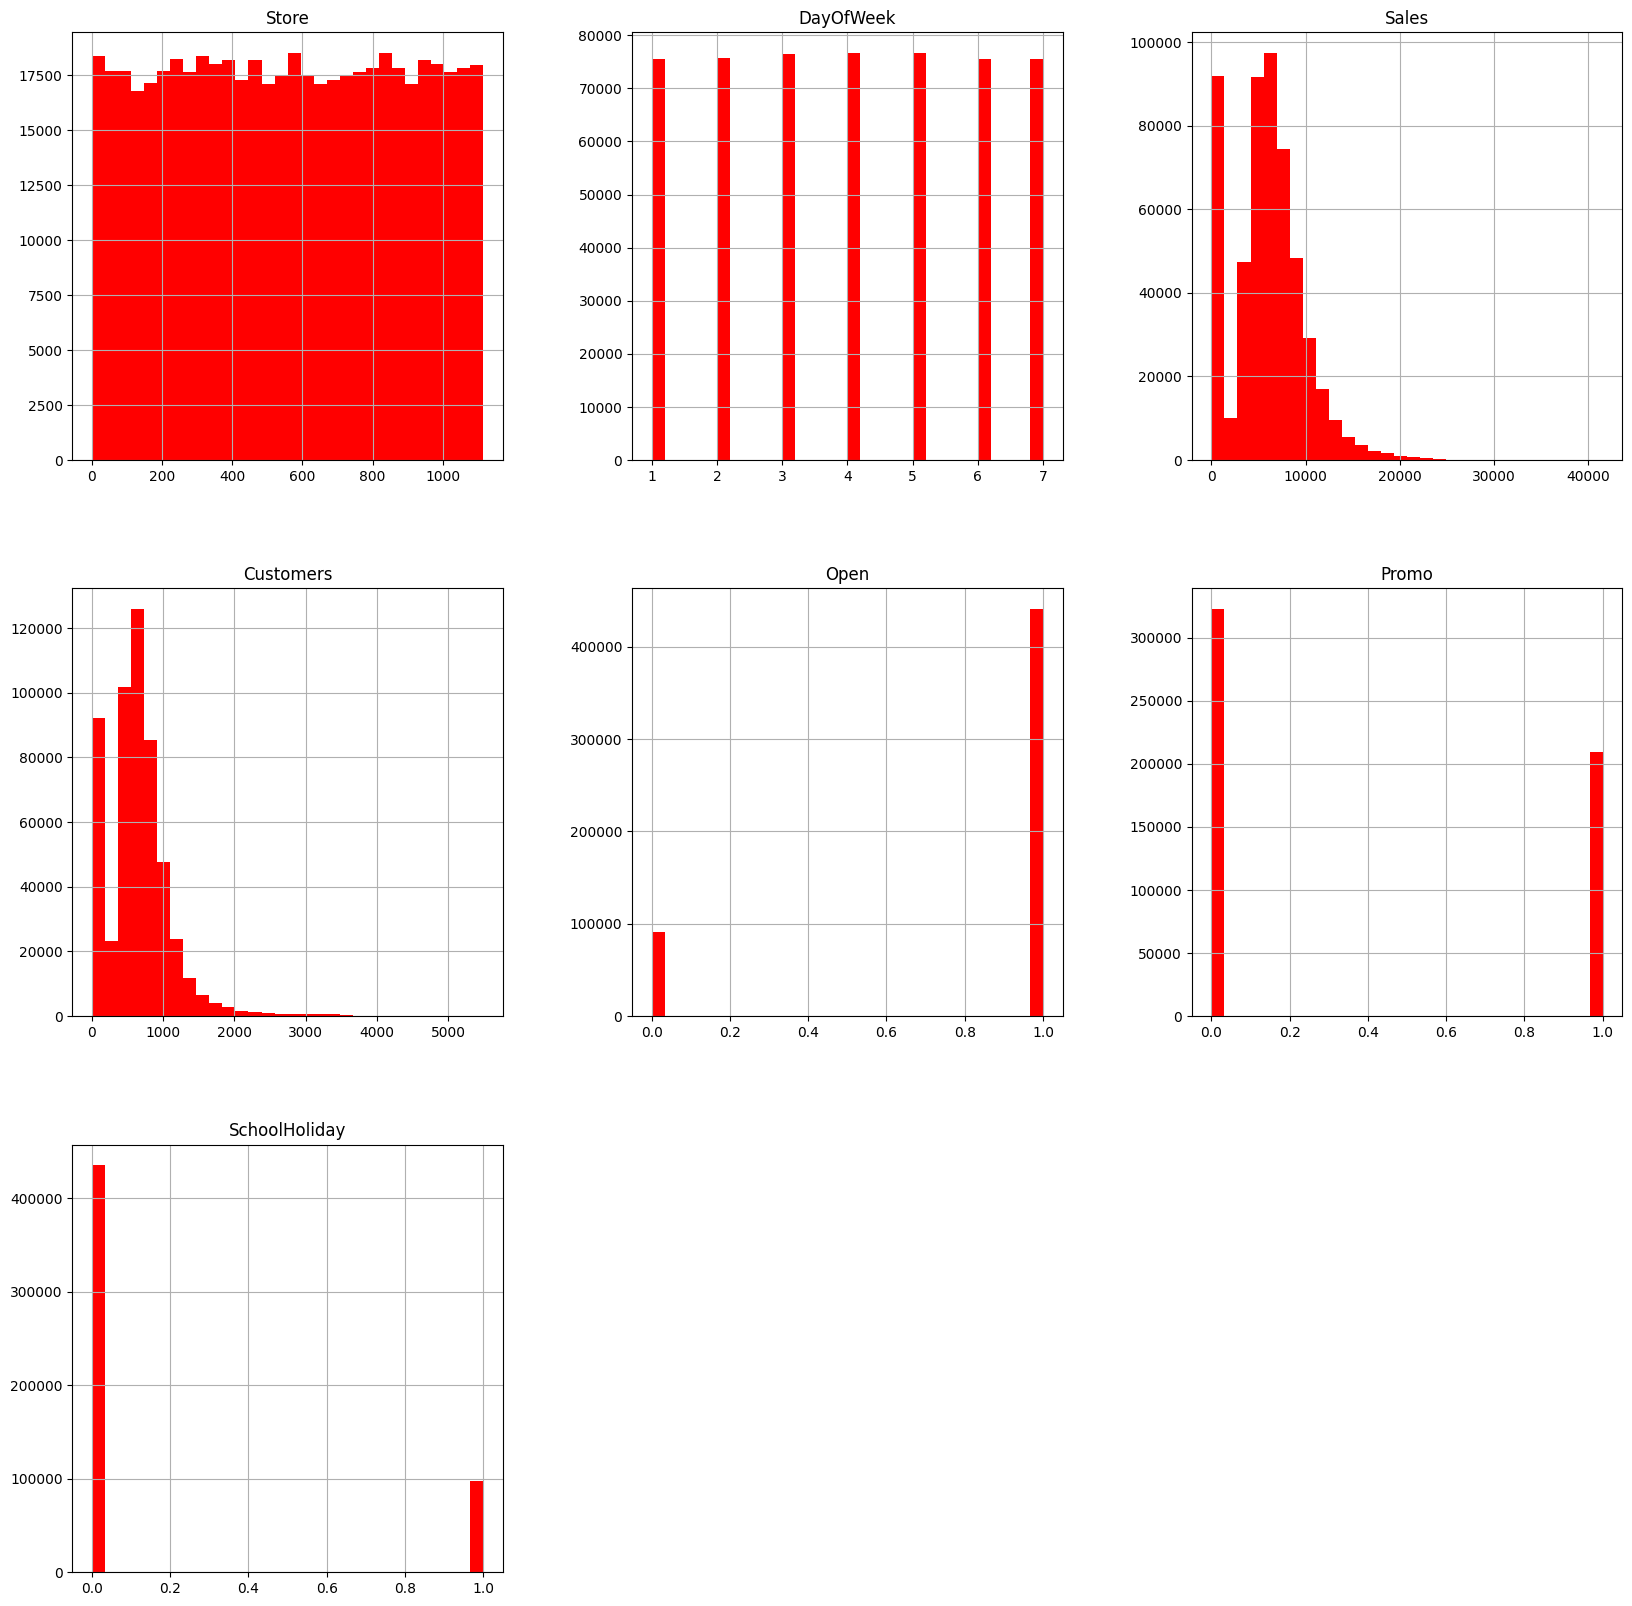

In [ ]:
sales_train_df.hist(bins = 30, figsize=(20,20), color = 'r')

In [ ]:
# Tivemos uma media bem parecida de transções nos dias da semana
# O valor total das vendas ficam em uma media de 0 a 5 mil euros
# Qtd de clientes em media é de 600 clientes por dia
# Haviam promoções em meatde ou 40% do tempo em que as lojas estavam abertas
# Apenas 18 a 20% do tempo havia feriado escolar quando as lojas estavam abertas

In [ ]:
sales_train_df['Customers'].max()

5494.0

In [ ]:
closed_train_df = [sales_train_df['Open'] == 0]
open_train_df = [sales_train_df['Open'] == 1]

In [ ]:
print('Total =', len (sales_train_df))
print('Total de dias de lojas abertas =', len(sales_train_df[open_train_df[0]]))
print('Total de dias de lojas fechadas =', len(sales_train_df[closed_train_df[0]]))

Total = 532483
Total de dias de lojas abertas = 441208
Total de dias de lojas fechadas = 91274


In [ ]:
172817/ len(store_info_df)

154.99282511210762

In [ ]:
closed_train_df[0].head()

,Open
0,False
1,False
2,False
3,False
4,False


In [ ]:
sales_train_df = sales_train_df[sales_train_df['Open'] == 1]

In [ ]:
sales_train_df.shape

(441208, 9)

In [ ]:
sales_train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5.0,2015-07-31,5263.0,555.0,1.0,1.0,0,1.0
1,2,5.0,2015-07-31,6064.0,625.0,1.0,1.0,0,1.0
2,3,5.0,2015-07-31,8314.0,821.0,1.0,1.0,0,1.0
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,1.0,0,1.0
4,5,5.0,2015-07-31,4822.0,559.0,1.0,1.0,0,1.0
...,...,...,...,...,...,...,...,...,...
532477,293,2.0,2014-03-11,4731.0,743.0,1.0,0.0,0.0,0.0
532478,294,2.0,2014-03-11,6207.0,915.0,1.0,0.0,0.0,0.0
532479,295,2.0,2014-03-11,4178.0,585.0,1.0,0.0,0.0,0.0
532480,296,2.0,2014-03-11,5643.0,737.0,1.0,0.0,0.0,0.0


In [ ]:
sales_train_df.drop(['Open'], axis = 1, inplace=True)

In [ ]:
sales_train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5.0,2015-07-31,5263.0,555.0,1.0,0,1.0
1,2,5.0,2015-07-31,6064.0,625.0,1.0,0,1.0
2,3,5.0,2015-07-31,8314.0,821.0,1.0,0,1.0
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,0,1.0
4,5,5.0,2015-07-31,4822.0,559.0,1.0,0,1.0


In [ ]:
sales_train_df.describe()

,Store,DayOfWeek,Sales,Customers,Promo,SchoolHoliday
count,441208.000000,441208.000000,441208.000000,441208.00000,441208.000000,441208.000000
mean,558.526382,3.517767,7103.842204,769.71253,0.458750,0.198802
std,321.886885,1.719875,3113.171413,402.35240,0.498296,0.399099
min,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000
25%,281.000000,2.000000,4997.000000,528.00000,0.000000,0.000000
50%,558.000000,3.000000,6520.000000,683.00000,0.000000,0.000000
75%,838.000000,5.000000,8530.000000,898.00000,1.000000,0.000000
max,1115.000000,7.000000,41551.000000,5494.00000,1.000000,1.000000


In [ ]:
# Podemos ver agora nossas médias mais certeiras calculando clientes e  vendas por dia

In [ ]:
store_info_df[store_info_df['CompetitionDistance'].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [ ]:
store_info_df[store_info_df['CompetitionOpenSinceMonth'].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
store_info_df[store_info_df['CompetitionOpenSinceYear'].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
store_info_df[store_info_df['Promo2'] == 0]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1107,1108,a,a,540.0,4.0,2004.0,0,NaN,NaN,NaN
1109,1110,c,c,900.0,9.0,2010.0,0,NaN,NaN,NaN
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
# Em geral, valores nulos d eoclunas numericas usamos a media pra preencher
# Mas como se trata de datas vamos utilizar o valor 0 para todos esses atributos

In [ ]:
str_cols = ['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth']
for str in str_cols:
  store_info_df[str].fillna(0, inplace = True)

/tmp/ipykernel_144/3996308523.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  store_info_df[str].fillna(0, inplace = True)


In [ ]:
# Para o atributo Competition Distance, podemos utilizar a media, pois se trata de um valor numero (km)

In [ ]:
store_info_df['CompetitionDistance'].fillna(store_info_df['CompetitionDistance'].mean(), inplace =True)

/tmp/ipykernel_144/2860464556.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  store_info_df['CompetitionDistance'].fillna(store_info_df['CompetitionDistance'].mean(), inplace =True)


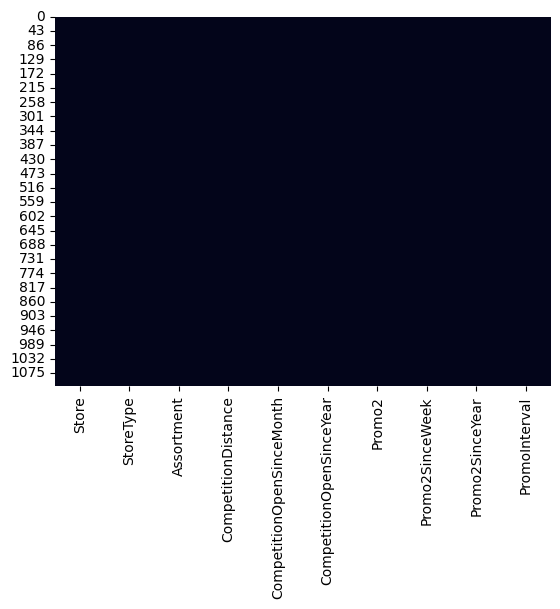

In [ ]:
sns.heatmap(store_info_df.isnull(), cbar = False);

array([[<Axes: title={'center': 'Store'}>,
        <Axes: title={'center': 'CompetitionDistance'}>,
        <Axes: title={'center': 'CompetitionOpenSinceMonth'}>],
       [<Axes: title={'center': 'CompetitionOpenSinceYear'}>,
        <Axes: title={'center': 'Promo2'}>,
        <Axes: title={'center': 'Promo2SinceWeek'}>],
       [<Axes: title={'center': 'Promo2SinceYear'}>, <Axes: >, <Axes: >]],
      dtype=object)

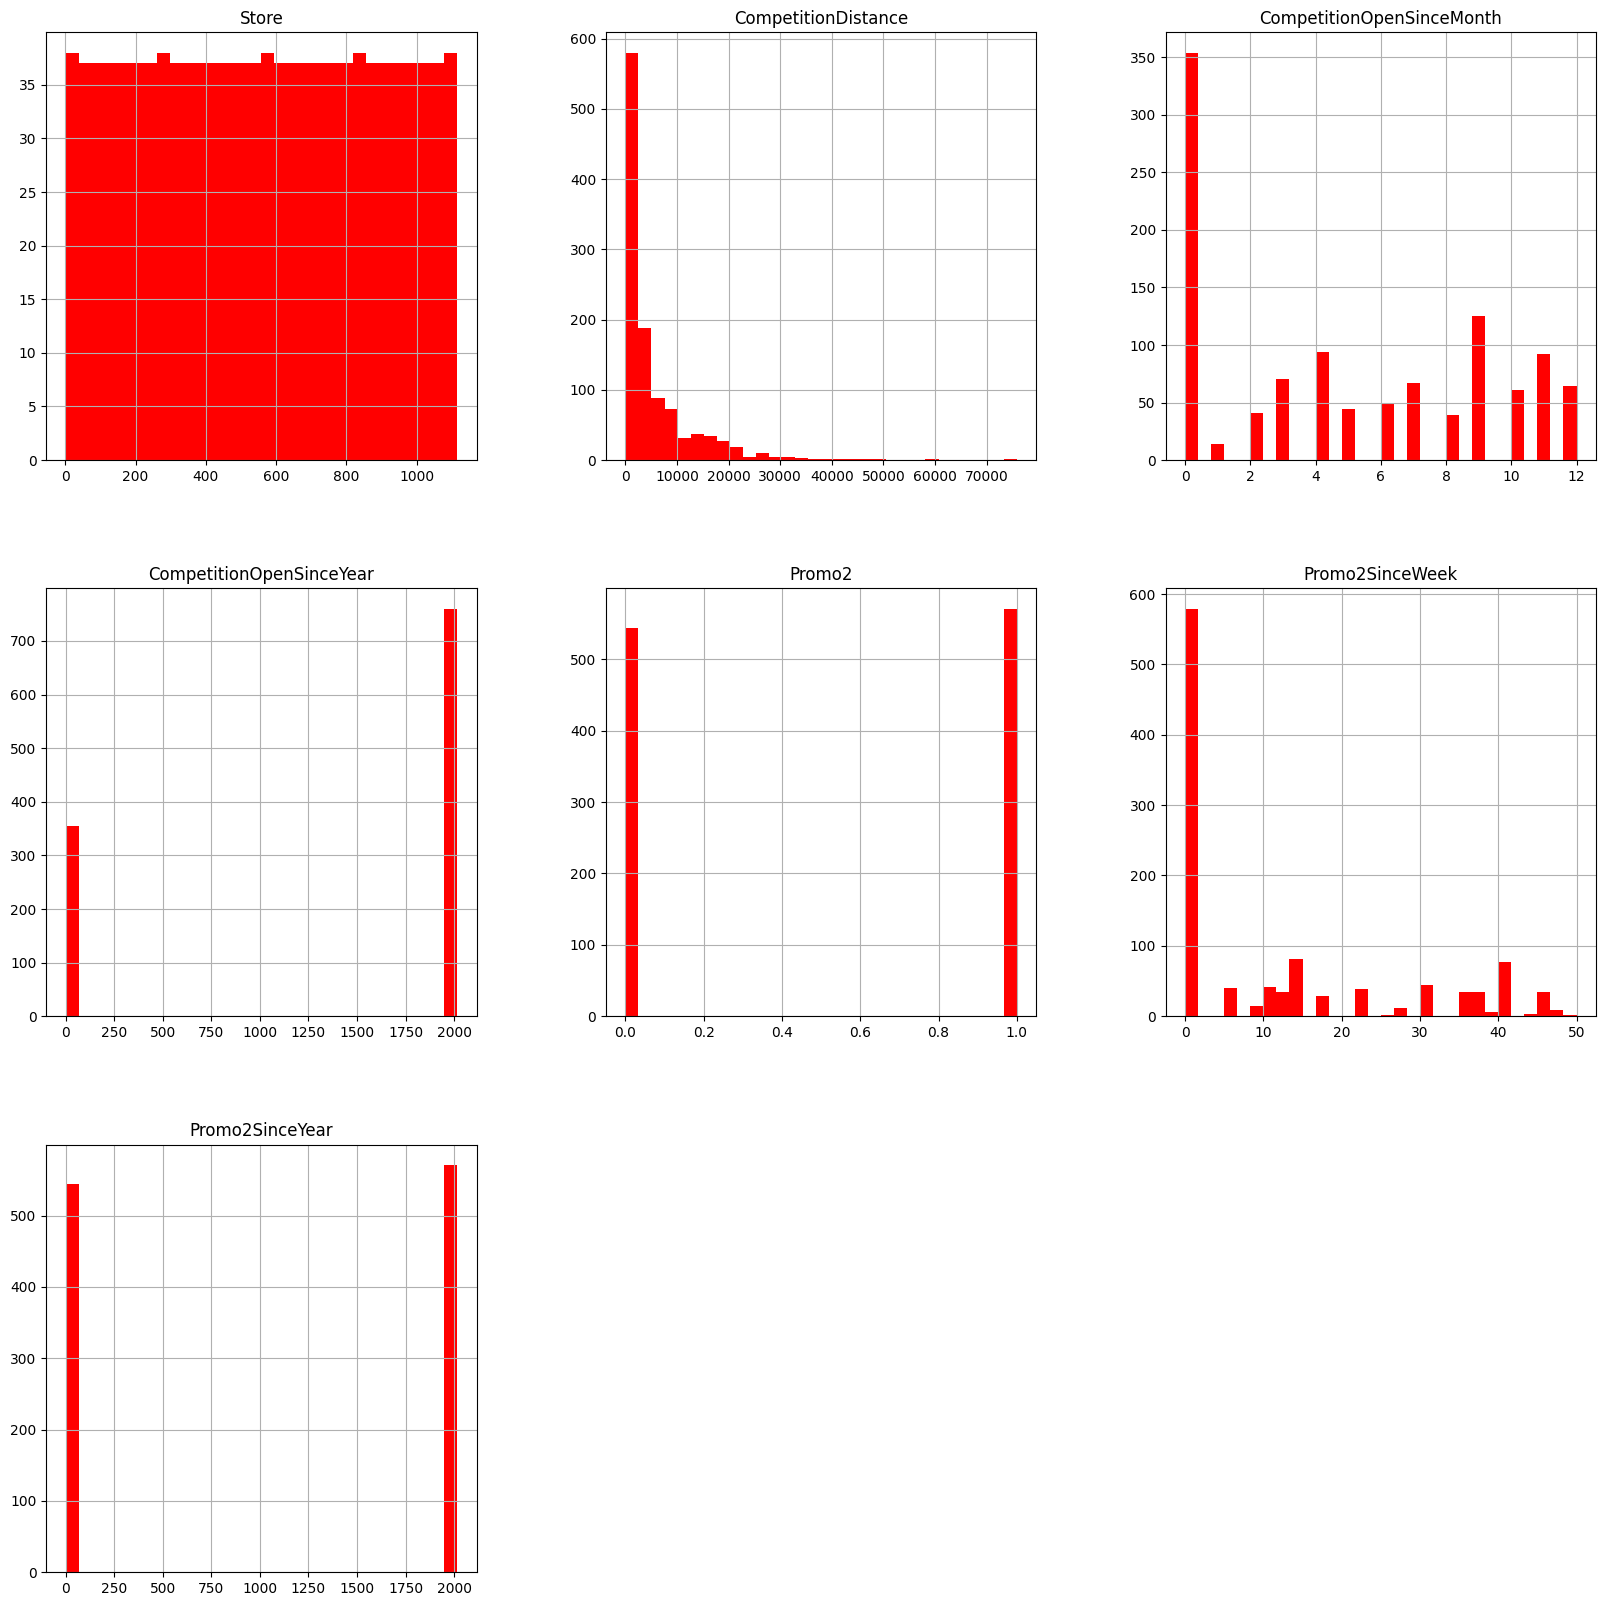

In [ ]:
store_info_df.hist(bins = 30, figsize=(20,20), color = 'r')

# Dados unidos (vendas + lojas)

In [ ]:
sales_train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5.0,2015-07-31,5263.0,555.0,1.0,0,1.0
1,2,5.0,2015-07-31,6064.0,625.0,1.0,0,1.0
2,3,5.0,2015-07-31,8314.0,821.0,1.0,0,1.0
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,0,1.0
4,5,5.0,2015-07-31,4822.0,559.0,1.0,0,1.0


In [ ]:
store_info_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


In [ ]:
sales_train_all_df = pd.merge(sales_train_df, store_info_df, how = 'inner', on = 'Store')

In [ ]:
sales_train_all_df.shape

(441208, 17)

In [ ]:
sales_train_all_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5.0,2015-07-31,5263.0,555.0,1.0,0,1.0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5.0,2015-07-31,6064.0,625.0,1.0,0,1.0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5.0,2015-07-31,8314.0,821.0,1.0,0,1.0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,0,1.0,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5.0,2015-07-31,4822.0,559.0,1.0,0,1.0,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


In [ ]:
sales_train_all_df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
441203,293,2.0,2014-03-11,4731.0,743.0,0.0,0.0,0.0,c,c,140.0,11.0,2007.0,0,0.0,0.0,0
441204,294,2.0,2014-03-11,6207.0,915.0,0.0,0.0,0.0,a,a,3150.0,5.0,2005.0,0,0.0,0.0,0
441205,295,2.0,2014-03-11,4178.0,585.0,0.0,0.0,0.0,a,a,210.0,11.0,2000.0,1,36.0,2013.0,"Mar,Jun,Sept,Dec"
441206,296,2.0,2014-03-11,5643.0,737.0,0.0,0.0,0.0,a,a,9580.0,5.0,2007.0,1,45.0,2014.0,"Feb,May,Aug,Nov"
441207,297,2.0,2014-03-11,5029.0,624.0,0.0,0.0,0.0,a,a,2300.0,9.0,2010.0,0,0.0,0.0,0


<Axes: >

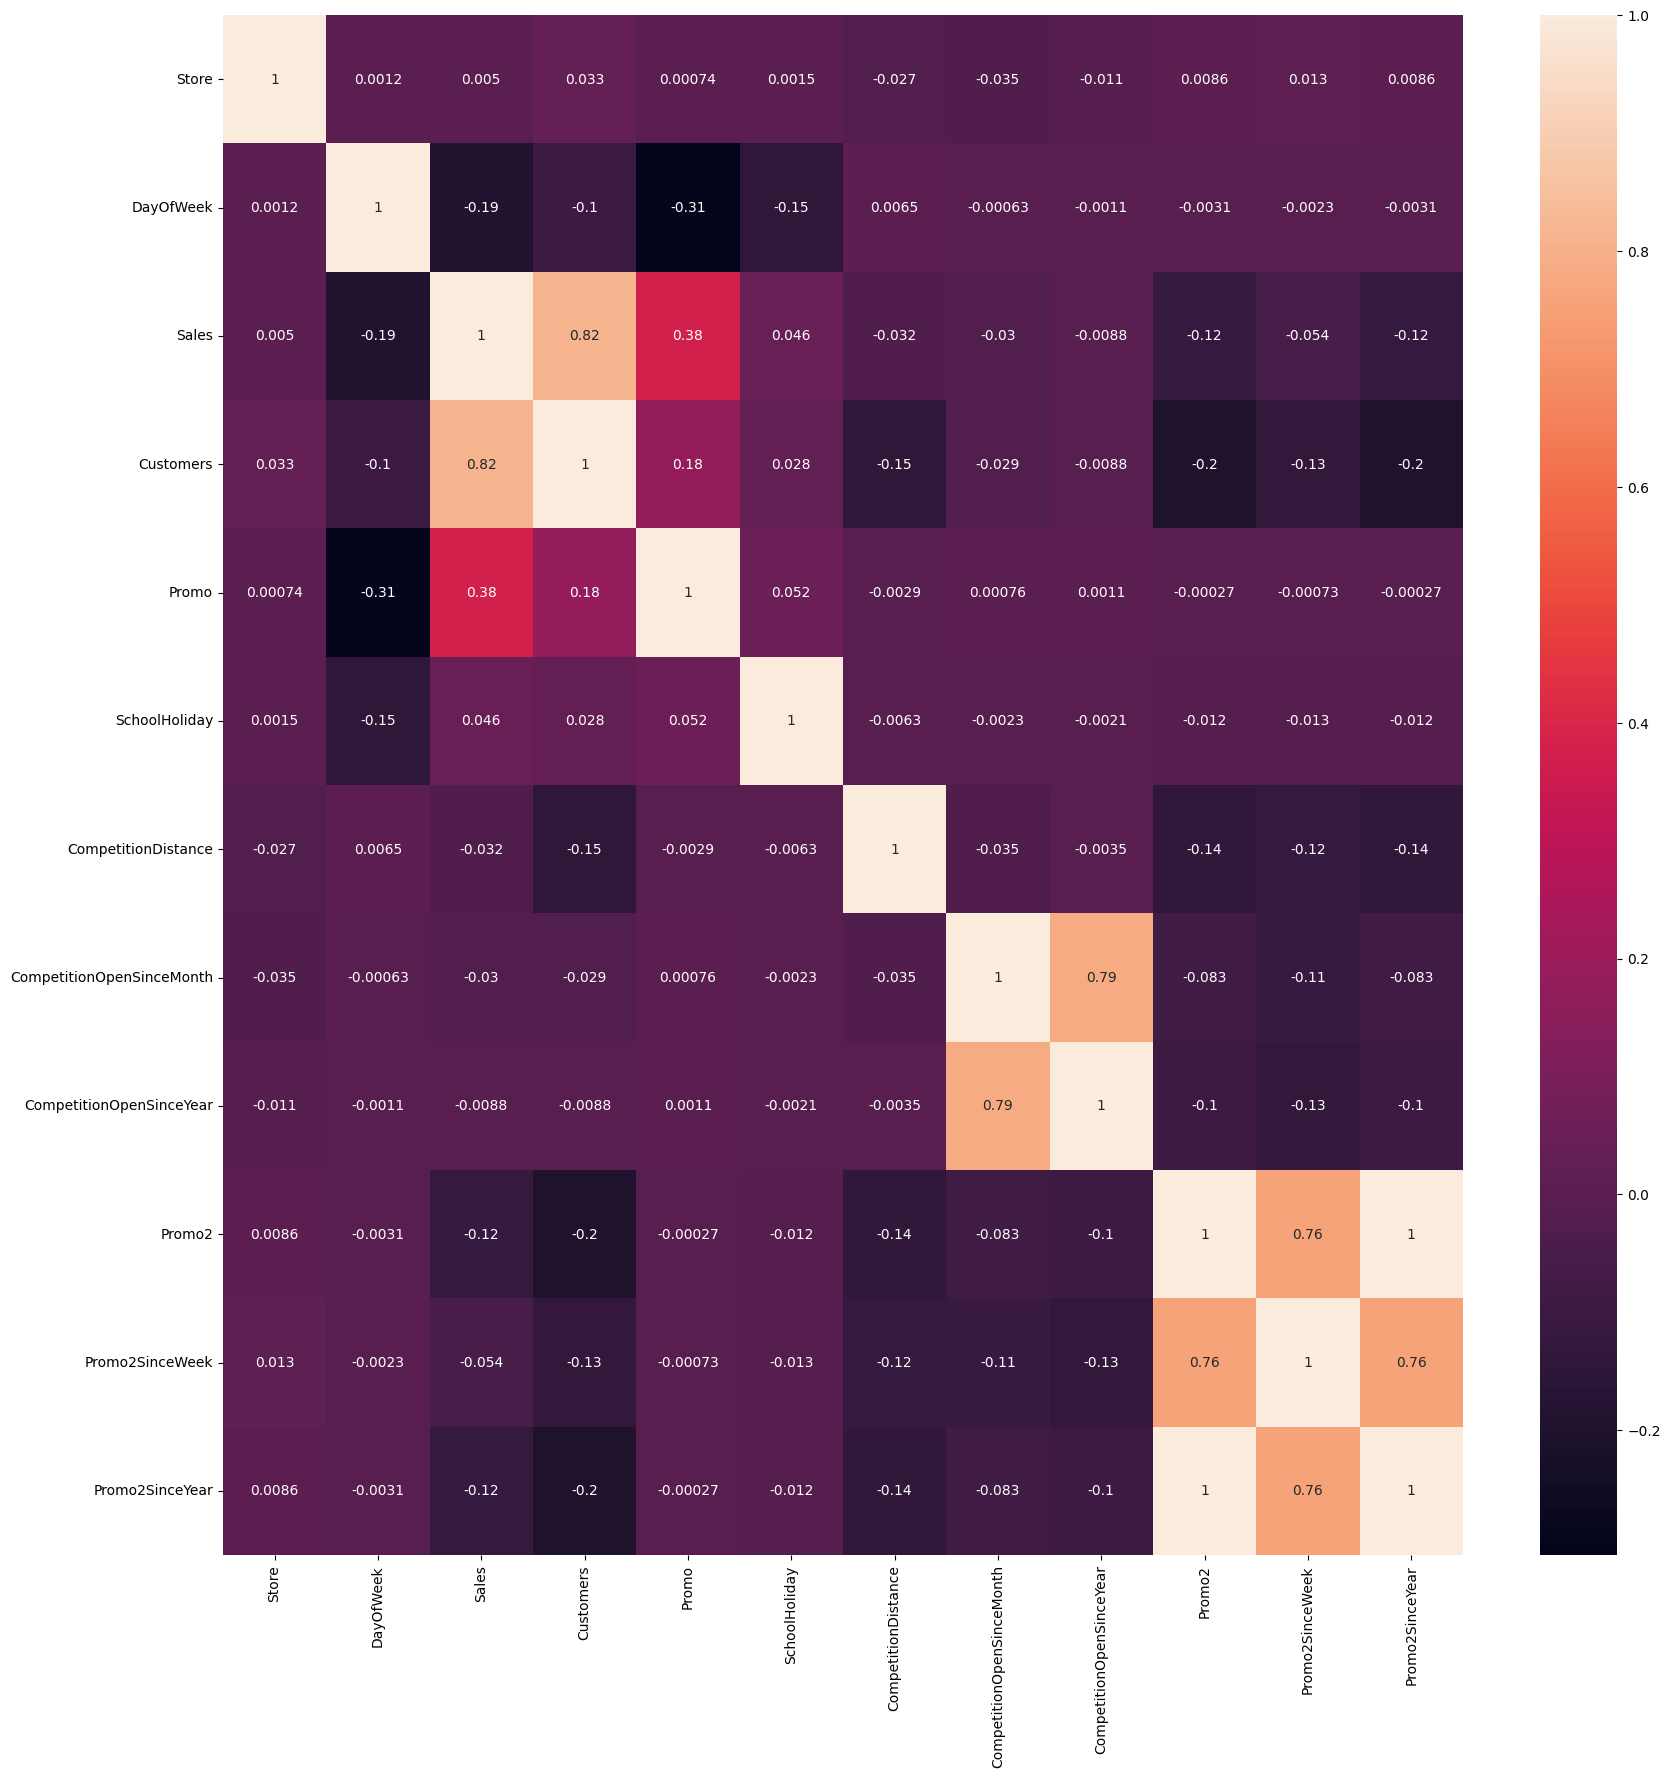

In [ ]:
correlations = sales_train_all_df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(20,20))
sns.heatmap(correlations, annot=True)

In [ ]:
# Podemos observar que Pormo2 nao influencia muito em Sales ou Customers, nao temos uma correlação muito forte, o que temos é uma negativa entre Promo2 e Customers
# É preciso mais análises específicas, mas vemos que quanto mais Promo2, menos customers estão na loja, com temos uma correlação negativa é o que dá a enteder.
# Vamos agora recriar esse mapa de correlações com um Ranking de correlação pra variavel de vendas

In [ ]:
correlations = sales_train_all_df.corr(numeric_only=True)['Sales'].sort_values()
correlations

,Sales
DayOfWeek,-0.191183
Promo2SinceYear,-0.121210
Promo2,-0.121188
Promo2SinceWeek,-0.054324
CompetitionDistance,-0.031527
CompetitionOpenSinceMonth,-0.030024
CompetitionOpenSinceYear,-0.008828
Store,0.004971
SchoolHoliday,0.046121
Promo,0.375514


In [ ]:
# 0,82 indica que quanto mais Customers mais vendas
# 0,36 indica que quanto mais Promoções, maior é o montante vendido pela loja.

In [ ]:
sales_train_all_df['Year'] = pd.DatetimeIndex(sales_train_all_df['Date']).year
sales_train_all_df['Month'] = pd.DatetimeIndex(sales_train_all_df['Date']).month
sales_train_all_df['Day'] = pd.DatetimeIndex(sales_train_all_df['Date']).day

In [ ]:
sales_train_all_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day
0,1,5.0,2015-07-31,5263.0,555.0,1.0,0,1.0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,31
1,2,5.0,2015-07-31,6064.0,625.0,1.0,0,1.0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31
2,3,5.0,2015-07-31,8314.0,821.0,1.0,0,1.0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,0,1.0,c,c,620.0,9.0,2009.0,0,0.0,0.0,0,2015,7,31
4,5,5.0,2015-07-31,4822.0,559.0,1.0,0,1.0,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0,2015,7,31


Text(0.5, 1.0, 'Média de vendas por mes')

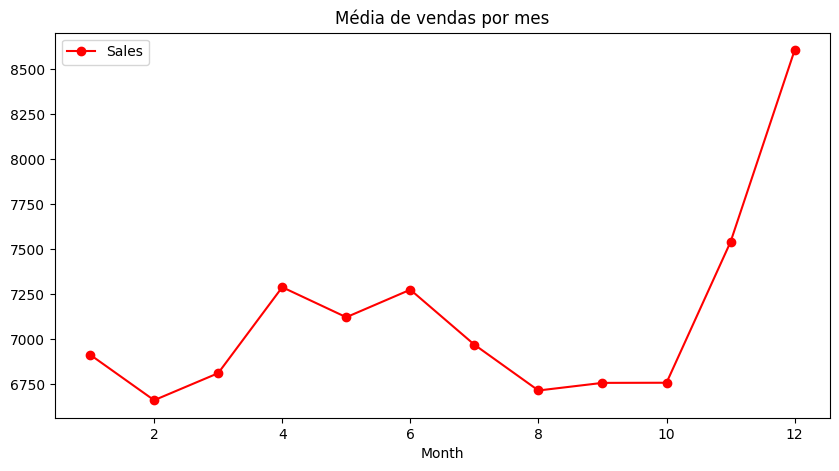

In [ ]:
axis = sales_train_all_df.groupby('Month')[['Sales']].mean().plot(figsize = (10,5), marker ='o', color = 'r')
axis.set_title('Média de vendas por mes')

Text(0.5, 1.0, 'Média de clientes por mes')

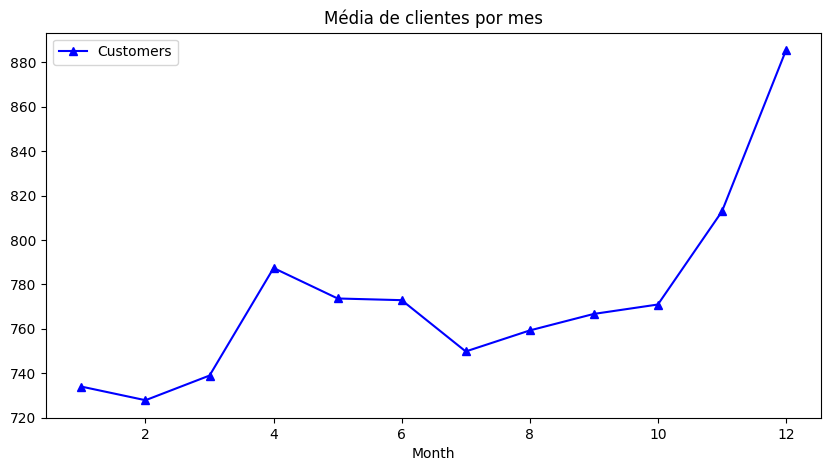

In [ ]:
axis = sales_train_all_df.groupby('Month')[['Customers']].mean().plot(figsize = (10,5), marker ='^', color = 'b')
axis.set_title('Média de clientes por mes')

Text(0.5, 1.0, 'Média de vendas por dia')

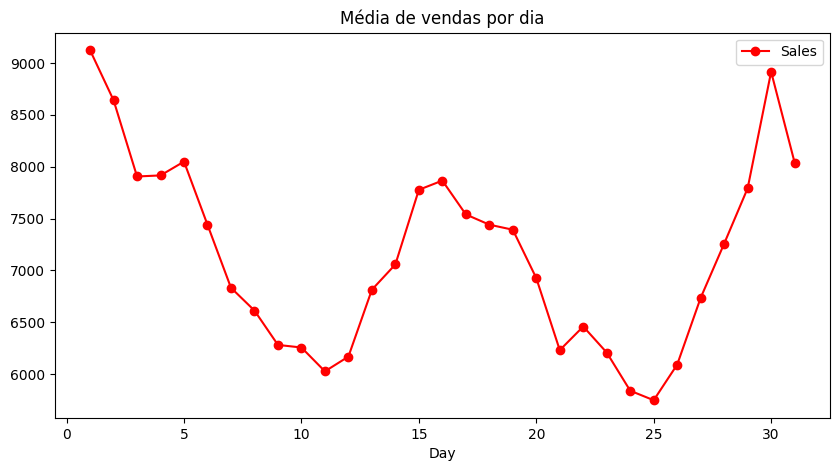

In [ ]:
axis = sales_train_all_df.groupby('Day')[['Sales']].mean().plot(figsize = (10,5), marker ='o', color = 'r')
axis.set_title('Média de vendas por dia')

Text(0.5, 1.0, 'Média de clientes por dia')

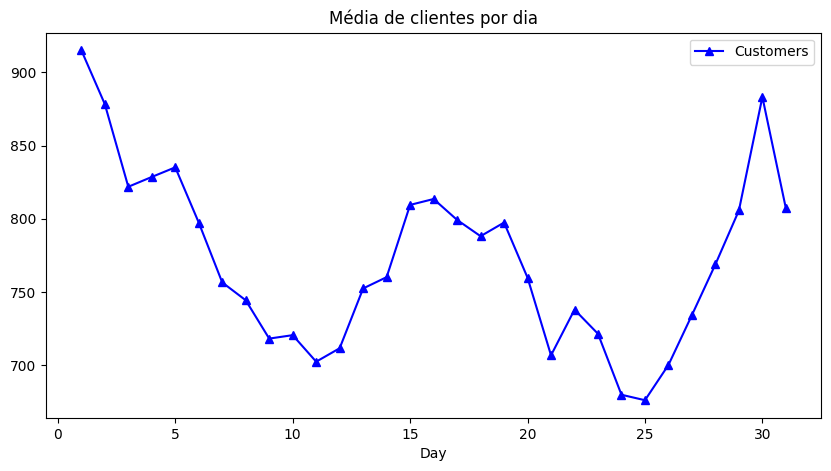

In [ ]:
axis = sales_train_all_df.groupby('Day')[['Customers']].mean().plot(figsize = (10,5), marker ='^', color = 'b')
axis.set_title('Média de clientes por dia')

Text(0.5, 1.0, 'Média de vendas por dia da semana')

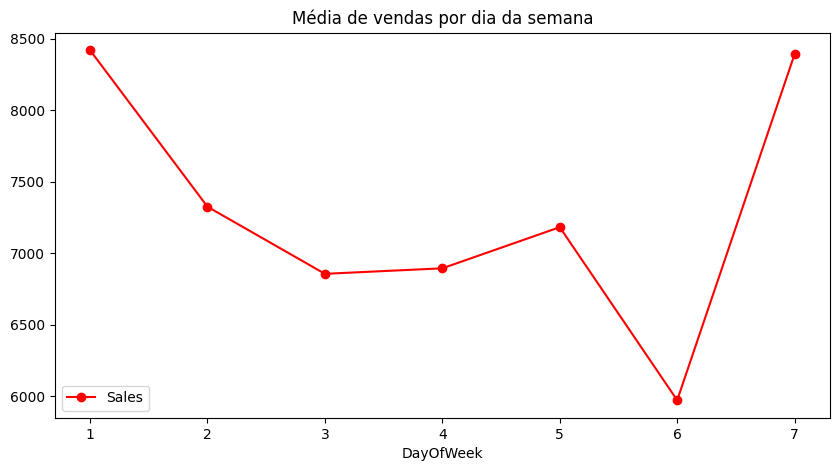

In [ ]:
axis = sales_train_all_df.groupby('DayOfWeek')[['Sales']].mean().plot(figsize = (10,5), marker ='o', color = 'r')
axis.set_title('Média de vendas por dia da semana')

Text(0.5, 1.0, 'Média de clientes por dia da semana')

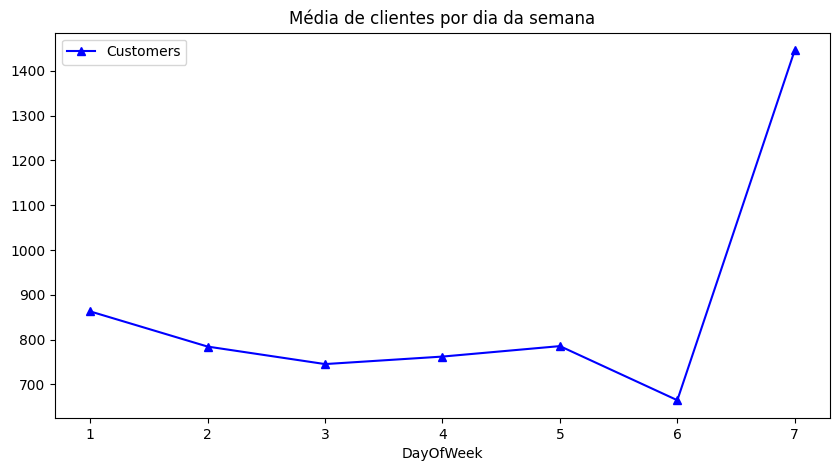

In [ ]:
axis = sales_train_all_df.groupby('DayOfWeek')[['Customers']].mean().plot(figsize = (10,5), marker ='^', color = 'b')
axis.set_title('Média de clientes por dia da semana')

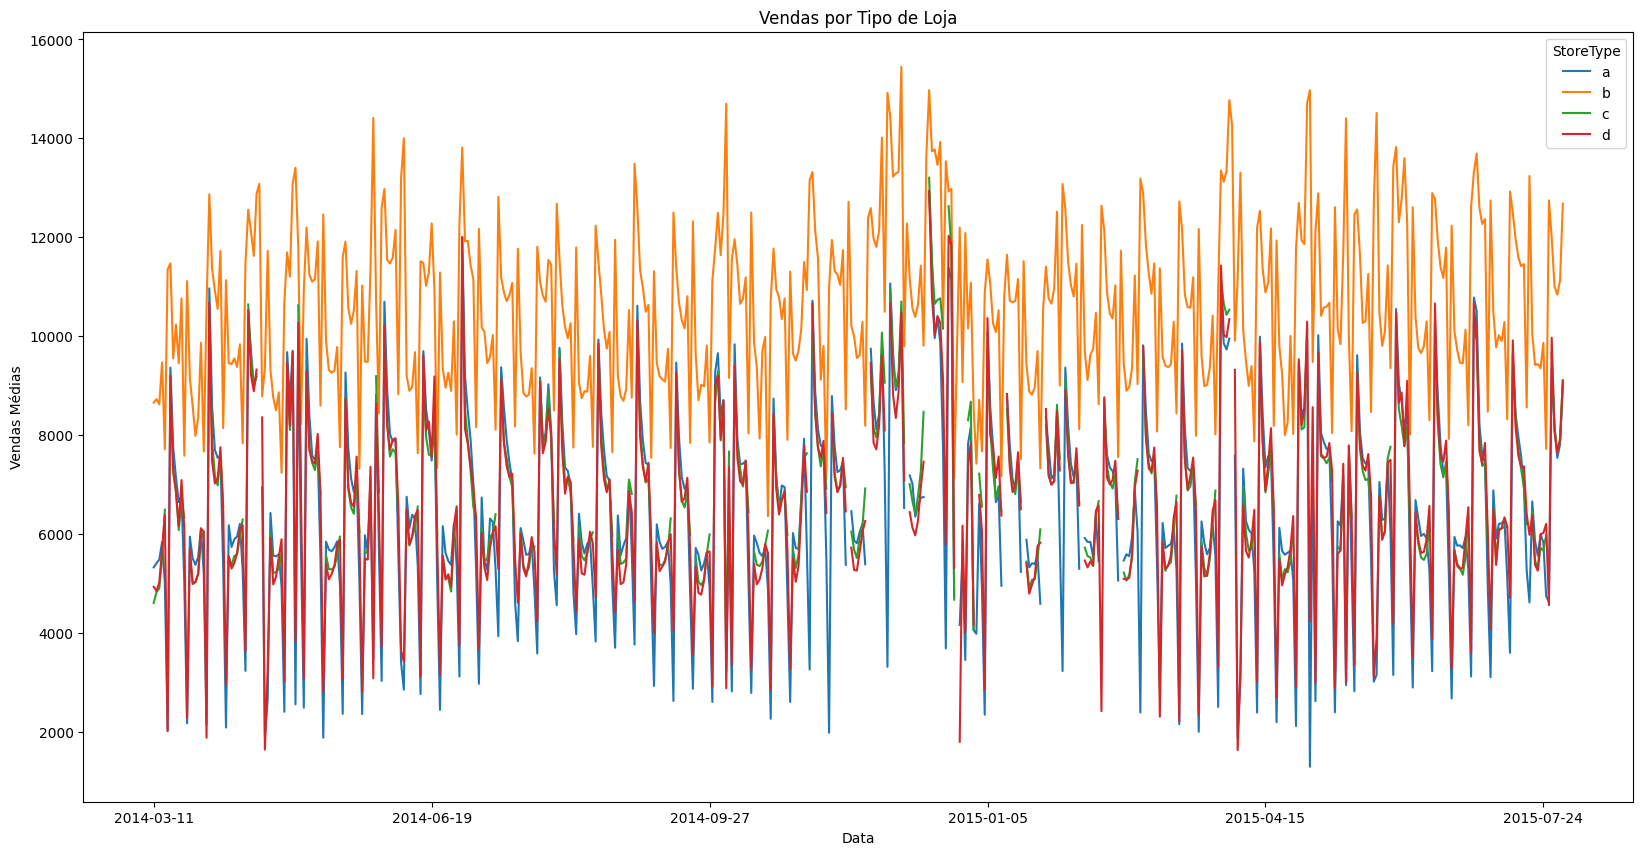

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10))

sales_train_all_df.groupby(['Date', 'StoreType'])['Sales'] \
    .mean() \
    .unstack() \
    .plot(ax=ax)

ax.set_title('Vendas por Tipo de Loja')
ax.set_xlabel('Data')
ax.set_ylabel('Vendas Médias')
ax.legend(title='StoreType')

plt.show()

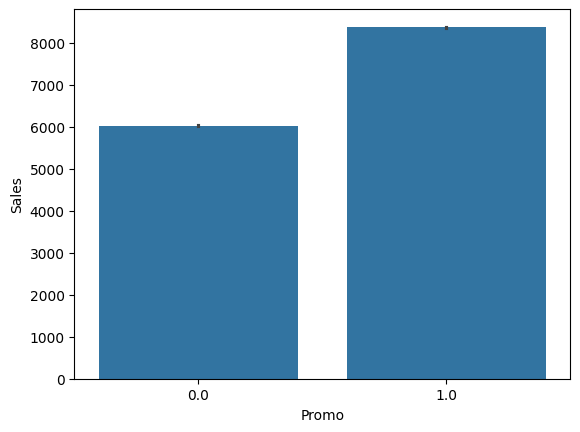

In [ ]:
sns.barplot(x = 'Promo', y = 'Sales', data = sales_train_all_df);

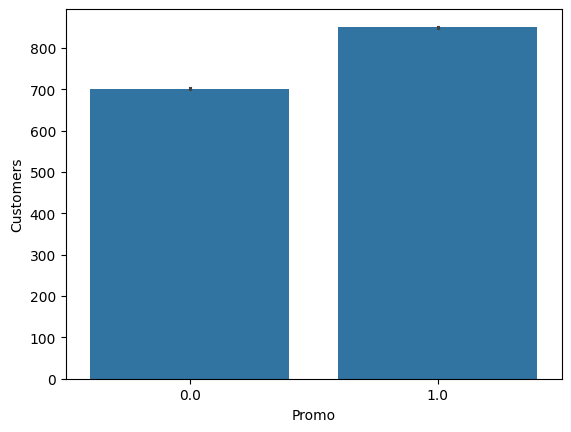

In [ ]:
sns.barplot(x = 'Promo', y = 'Customers', data = sales_train_all_df);

In [ ]:
# Observamos que a promoção influencia diretamente no aumento de cleintes na çloja e no montante final de vendas

# Treinamento do modelo - Parte 1

---



In [ ]:
!
!pip install prophet
from prophet import Prophet

In [ ]:
# Nosso objetivo é passar o id de uma determinada loja e nosso algoritmo realizar todas as previsõs pra essa loja em específico
# Vamos renomear as colunas Sales e Date, Date = ds, Sales = y

In [ ]:
# Date: ds
# Sales: y
def sales_prediction(store_id, sales_df, periods):
  sales_df = sales_df[sales_df['Store'] == store_id]
  sales_df = sales_df[['Date', 'Sales']].rename(columns = {'Date': 'ds', 'Sales': 'y'})
  sales_df = sales_df.sort_values(by = 'ds')

  model = Prophet()
  model.fit(sales_df)
  future = model.make_future_dataframe(periods = periods)
  forecast = model.predict(future)
  figure1 = model.plot(forecast, xlabel = 'Data', ylabel = 'Vendas')
  figure2 = model.plot_components(forecast)

  return sales_df, forecast

In [ ]:
#df = sales_prediction(10, sales_train_all_df, 60)
#df

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


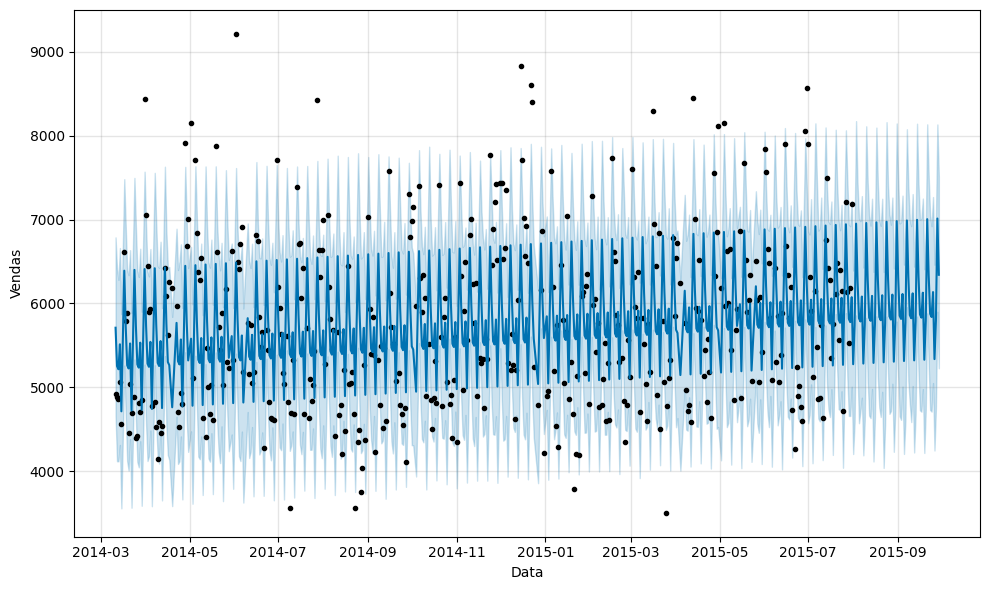

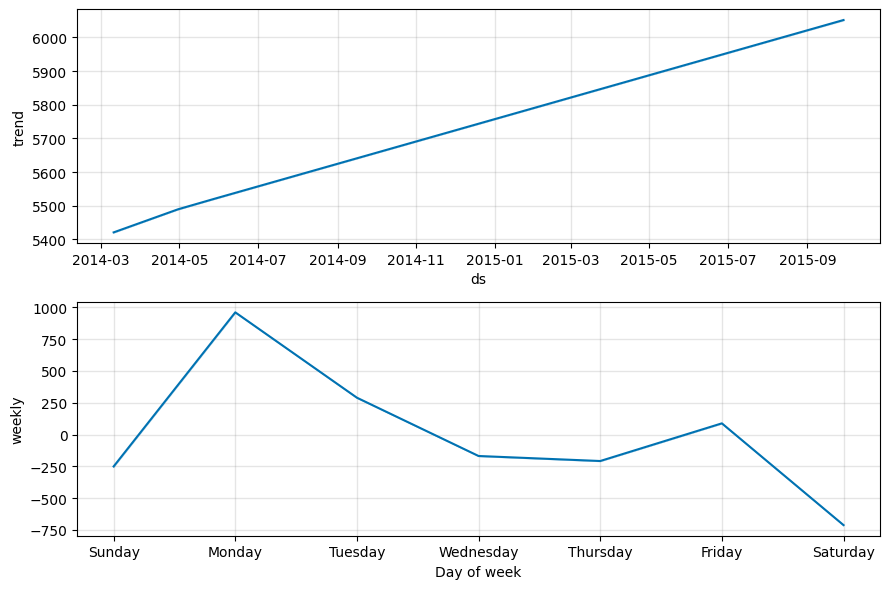

In [ ]:
df_origin, df_prediction = sales_prediction(10, sales_train_all_df, 60)

In [ ]:
# Temos um grafico trend de tendencia, que mostra
# Temos um grafico weekly de dias da semana, que mostra
# Temos um grafico yearly de meses do ano, que mostra
# Vamos entende rentão o que tem no df_orifin e o que tem no df_prediction

In [ ]:
df_origin.shape, df_prediction.shape

((422, 2), (482, 16))

In [ ]:
df_prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-03-11,5421.105496,4667.153947,6787.086746,5421.105496,5421.105496,289.748519,289.748519,289.748519,289.748519,289.748519,289.748519,0.0,0.0,0.0,5710.854014
1,2014-03-12,5422.482557,4120.019547,6408.847169,5422.482557,5422.482557,-168.507279,-168.507279,-168.507279,-168.507279,-168.507279,-168.507279,0.0,0.0,0.0,5253.975279
2,2014-03-13,5423.859619,4119.096908,6281.175638,5423.859619,5423.859619,-207.966501,-207.966501,-207.966501,-207.966501,-207.966501,-207.966501,0.0,0.0,0.0,5215.893117
3,2014-03-14,5425.236680,4314.043108,6659.908426,5425.236680,5425.236680,88.137064,88.137064,88.137064,88.137064,88.137064,88.137064,0.0,0.0,0.0,5513.373745
4,2014-03-15,5426.613742,3558.800575,5873.157825,5426.613742,5426.613742,-711.714357,-711.714357,-711.714357,-711.714357,-711.714357,-711.714357,0.0,0.0,0.0,4714.899385


In [ ]:
df_prediction.tail(60)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
422,2015-08-01,5987.716639,4206.195108,6392.548430,5987.716639,5987.716639,-711.714357,-711.714357,-711.714357,-711.714357,-711.714357,-711.714357,0.0,0.0,0.0,5276.002281
423,2015-08-02,5988.802957,4582.925361,6901.216788,5988.802957,5988.802957,-250.637811,-250.637811,-250.637811,-250.637811,-250.637811,-250.637811,0.0,0.0,0.0,5738.165146
424,2015-08-03,5989.889276,5857.073925,8172.433364,5989.889276,5989.889276,960.940366,960.940366,960.940366,960.940366,960.940366,960.940366,0.0,0.0,0.0,6950.829642
425,2015-08-04,5990.975595,5190.622514,7432.252071,5990.975531,5990.975595,289.748519,289.748519,289.748519,289.748519,289.748519,289.748519,0.0,0.0,0.0,6280.724113
426,2015-08-05,5992.061913,4573.285723,7011.388137,5992.059604,5992.065247,-168.507279,-168.507279,-168.507279,-168.507279,-168.507279,-168.507279,0.0,0.0,0.0,5823.554635
427,2015-08-06,5993.148232,4716.381872,6980.980889,5993.143045,5993.155525,-207.966501,-207.966501,-207.966501,-207.966501,-207.966501,-207.966501,0.0,0.0,0.0,5785.181731
428,2015-08-07,5994.234551,4876.882340,7279.305816,5994.222837,5994.247074,88.137064,88.137064,88.137064,88.137064,88.137064,88.137064,0.0,0.0,0.0,6082.371615
429,2015-08-08,5995.320870,4190.143603,6427.816449,5995.303152,5995.340970,-711.714357,-711.714357,-711.714357,-711.714357,-711.714357,-711.714357,0.0,0.0,0.0,5283.606512
430,2015-08-09,5996.407188,4609.892587,6925.900666,5996.377874,5996.437679,-250.637811,-250.637811,-250.637811,-250.637811,-250.637811,-250.637811,0.0,0.0,0.0,5745.769377
431,2015-08-10,5997.493507,5828.231007,8110.461929,5997.456102,5997.532007,960.940366,960.940366,960.940366,960.940366,960.940366,960.940366,0.0,0.0,0.0,6958.433873


In [ ]:
df_prediction.tail(60).to_csv('previsoes_vendas.csv')

# Treinamento do modelo - Parte 2

In [ ]:
def sales_prediction(store_id, sales_df, holidays, periods):
  sales_df = sales_df[sales_df['Store'] == store_id]
  sales_df = sales_df[['Date', 'Sales']].rename(columns = {'Date': 'ds', 'Sales': 'y'})
  sales_df = sales_df.sort_values(by = 'ds')

  model = Prophet(holidays=holidays)
  model.fit(sales_df)
  future = model.make_future_dataframe(periods = periods)
  forecast = model.predict(future)
  figure1 = model.plot(forecast, xlabel = 'Data', ylabel = 'Vendas')
  figure2 = model.plot_components(forecast)

  return sales_df, forecast

In [ ]:
school_holidays = sales_train_all_df[sales_train_all_df['SchoolHoliday'] == 1].loc[:, 'Date'].values
school_holidays.shape

(87713,)

In [ ]:
school_holidays

array(['2015-07-31', '2015-07-31', '2015-07-31', ..., '2014-03-11',
       '2014-03-11', '2014-03-11'], dtype=object)

In [ ]:
len(np.unique(school_holidays))

248

In [ ]:
state_holidays = sales_train_all_df[(sales_train_all_df['StateHoliday'] == 'a') |
                                    (sales_train_all_df['StateHoliday'] == 'b') |
                                    (sales_train_all_df['StateHoliday'] == 'c')].loc[:,'Date'].values

In [ ]:
state_holidays.shape

(545,)

In [ ]:
len(np.unique(state_holidays))

19

In [ ]:
state_holidays = pd.DataFrame({'ds': pd.to_datetime(state_holidays),
                               'holiday': 'state_holiday'})
state_holidays

,ds,holiday
0,2015-06-04,state_holiday
1,2015-06-04,state_holiday
2,2015-06-04,state_holiday
3,2015-06-04,state_holiday
4,2015-06-04,state_holiday
...,...,...
540,2014-04-18,state_holiday
541,2014-04-18,state_holiday
542,2014-04-18,state_holiday
543,2014-04-18,state_holiday


In [ ]:
school_holidays = pd.DataFrame({'ds': pd.to_datetime(school_holidays),
                               'holiday': 'school_holiday'})
school_holidays

,ds,holiday
0,2015-07-31,school_holiday
1,2015-07-31,school_holiday
2,2015-07-31,school_holiday
3,2015-07-31,school_holiday
4,2015-07-31,school_holiday
...,...,...
87708,2014-03-11,school_holiday
87709,2014-03-11,school_holiday
87710,2014-03-11,school_holiday
87711,2014-03-11,school_holiday


In [ ]:
school_state_holidays = pd.concat((state_holidays, school_holidays))
school_state_holidays

,ds,holiday
0,2015-06-04,state_holiday
1,2015-06-04,state_holiday
2,2015-06-04,state_holiday
3,2015-06-04,state_holiday
4,2015-06-04,state_holiday
...,...,...
87708,2014-03-11,school_holiday
87709,2014-03-11,school_holiday
87710,2014-03-11,school_holiday
87711,2014-03-11,school_holiday


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


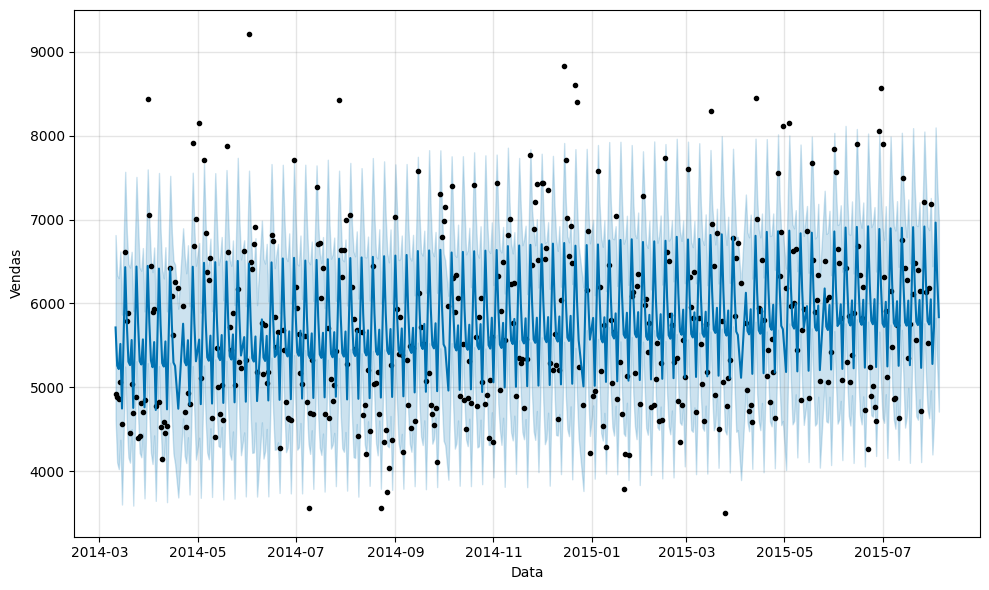

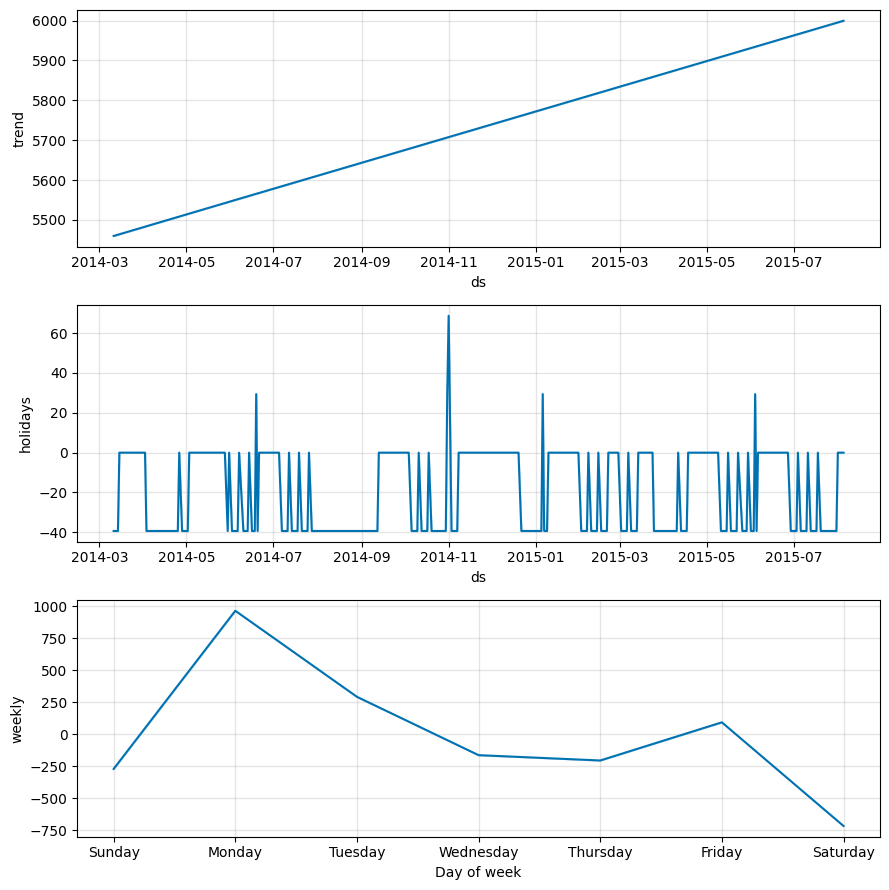

In [ ]:
df_original, df_prediction = sales_prediction(10, sales_train_all_df, school_state_holidays, 5)

In [ ]:
df_prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,...,state_holiday,state_holiday_lower,state_holiday_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-03-11,5459.881411,4628.321380,6814.912815,5459.881411,5459.881411,254.104146,254.104146,254.104146,-39.304783,...,0.0,0.0,0.0,293.408929,293.408929,293.408929,0.0,0.0,0.0,5713.985557
1,2014-03-12,5460.942448,4105.177286,6334.781973,5460.942448,5460.942448,-201.970963,-201.970963,-201.970963,-39.304783,...,0.0,0.0,0.0,-162.666180,-162.666180,-162.666180,0.0,0.0,0.0,5258.971485
2,2014-03-13,5462.003485,4026.386542,6302.658006,5462.003485,5462.003485,-243.640898,-243.640898,-243.640898,-39.304783,...,0.0,0.0,0.0,-204.336115,-204.336115,-204.336115,0.0,0.0,0.0,5218.362588
3,2014-03-14,5463.064523,4375.641887,6620.688730,5463.064523,5463.064523,54.646402,54.646402,54.646402,-39.304783,...,0.0,0.0,0.0,93.951185,93.951185,93.951185,0.0,0.0,0.0,5517.710924
4,2014-03-15,5464.125560,3604.642083,5867.745667,5464.125560,5464.125560,-716.194492,-716.194492,-716.194492,0.000000,...,0.0,0.0,0.0,-716.194492,-716.194492,-716.194492,0.0,0.0,0.0,4747.931068


In [ ]:
df_prediction.tail(60)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,...,state_holiday,state_holiday_lower,state_holiday_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
367,2015-05-29,5927.896506,4888.450598,7103.267759,5927.896506,5927.896506,54.646402,54.646402,54.646402,-39.304783,...,0.000000,0.000000,0.000000,93.951185,93.951185,93.951185,0.0,0.0,0.0,5982.542908
368,2015-05-30,5928.949744,4074.855623,6337.228506,5928.949744,5928.949744,-716.194492,-716.194492,-716.194492,0.000000,...,0.000000,0.000000,0.000000,-716.194492,-716.194492,-716.194492,0.0,0.0,0.0,5212.755252
369,2015-06-01,5931.056219,5670.204237,8031.784845,5931.056219,5931.056219,926.781036,926.781036,926.781036,-39.304783,...,0.000000,0.000000,0.000000,966.085819,966.085819,966.085819,0.0,0.0,0.0,6857.837255
370,2015-06-02,5932.109457,5068.239325,7380.580131,5932.109457,5932.109457,254.104146,254.104146,254.104146,-39.304783,...,0.000000,0.000000,0.000000,293.408929,293.408929,293.408929,0.0,0.0,0.0,6186.213602
371,2015-06-03,5933.162695,4567.941131,6935.423502,5933.162695,5933.162695,-201.970963,-201.970963,-201.970963,-39.304783,...,0.000000,0.000000,0.000000,-162.666180,-162.666180,-162.666180,0.0,0.0,0.0,5731.191731
372,2015-06-04,5934.215932,4616.653333,6946.948430,5934.215932,5934.215932,-174.945091,-174.945091,-174.945091,29.391023,...,68.695807,68.695807,68.695807,-204.336115,-204.336115,-204.336115,0.0,0.0,0.0,5759.270841
373,2015-06-05,5935.269170,4839.144463,7169.451780,5935.269170,5935.269170,54.646402,54.646402,54.646402,-39.304783,...,0.000000,0.000000,0.000000,93.951185,93.951185,93.951185,0.0,0.0,0.0,5989.915572
374,2015-06-06,5936.322408,4133.421428,6378.490305,5936.322408,5936.322408,-716.194492,-716.194492,-716.194492,0.000000,...,0.000000,0.000000,0.000000,-716.194492,-716.194492,-716.194492,0.0,0.0,0.0,5220.127915
375,2015-06-08,5938.428883,5762.167246,8115.373190,5938.428883,5938.428883,966.085819,966.085819,966.085819,0.000000,...,0.000000,0.000000,0.000000,966.085819,966.085819,966.085819,0.0,0.0,0.0,6904.514702
376,2015-06-09,5939.482121,5123.474668,7284.495169,5939.482121,5939.482121,293.408929,293.408929,293.408929,0.000000,...,0.000000,0.000000,0.000000,293.408929,293.408929,293.408929,0.0,0.0,0.0,6232.891049
